In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv('Dataset/bank-full.csv',sep=';')
df_backup = df.copy()

display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


None

In [9]:
df_numerica = df[['age','balance','duration','campaign','pdays','previous']]

In [10]:
display(df.sample(10))

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
24086,44,blue-collar,married,secondary,no,1324,yes,no,telephone,25,oct,119,1,89,2,other,no
40724,58,unemployed,married,secondary,no,687,yes,no,cellular,7,aug,221,1,99,2,success,yes
24775,48,management,married,tertiary,no,1741,yes,yes,telephone,18,nov,40,1,-1,0,unknown,no
10612,51,self-employed,married,tertiary,no,2007,no,no,unknown,16,jun,1021,1,-1,0,unknown,no
10525,44,management,married,unknown,no,2982,no,no,unknown,16,jun,55,2,-1,0,unknown,no
17416,30,admin.,married,secondary,no,39,yes,no,cellular,28,jul,101,3,-1,0,unknown,no
6057,37,blue-collar,single,secondary,no,3344,yes,no,unknown,26,may,85,5,-1,0,unknown,no
27802,46,management,married,tertiary,no,460,no,no,cellular,28,jan,56,1,-1,0,unknown,no
13419,45,management,divorced,tertiary,no,702,no,yes,cellular,9,jul,110,1,-1,0,unknown,no
26026,42,management,divorced,tertiary,no,16,no,no,cellular,19,nov,140,3,-1,0,unknown,no


---------------------------------------------------------------------------------------------------------------------------------------------

PERGUNTA: A pessoa estar ou não devendo afeta se ela vai ou não contratar o serviço?

In [11]:
df_binaria = df[['default','housing','loan','y']]

In [12]:
map_bin = {'yes':1,'no':0}
df_binaria = df_binaria.replace(map_bin)

#display(df_binaria[['default','y']].value_counts())

df_default = df_binaria[['default','y']]

df_0 = df_default[df_default['default']==0]
df_1 = df_default[df_default['default']==1]

total_0 = df_0['y'].count()
print(f'Número de pessoas NÃO inadimplentes: {total_0}')
display((df_0.value_counts()/df_0['y'].count())*100)

print()

total_1 = df_1['y'].count()
print(f'Número de pessoas inadimplentes: {total_1}')
display((df_1.value_counts()/df_1['y'].count())*100)

Número de pessoas NÃO inadimplentes: 44396


C:\Users\User\AppData\Local\Temp\ipykernel_17156\986305233.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_binaria = df_binaria.replace(map_bin)


default  y
0        0    88.203892
         1    11.796108
Name: count, dtype: float64


Número de pessoas inadimplentes: 815


default  y
1        0    93.619632
         1     6.380368
Name: count, dtype: float64

O fato de ter muito menos pessoas inadimplentes afeta essa porcentagem?

CONCLUSÃO: O fato de a pessoa estar devendo ou não, não afeta muito o fato de que ela aplicou ou não o dinheiro, o que é curioso...

---------------------------------------------------------------------------------------------------------------------------------------------

PERGUNTA: A idade influencia se a pessoa vai ou não contratar o servicço?

SEPARAR POR FAIXA ETÁRIA

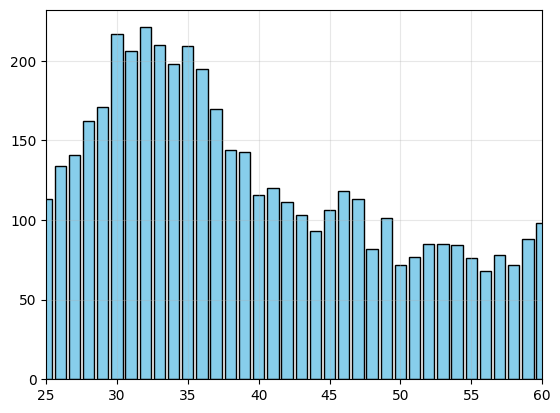

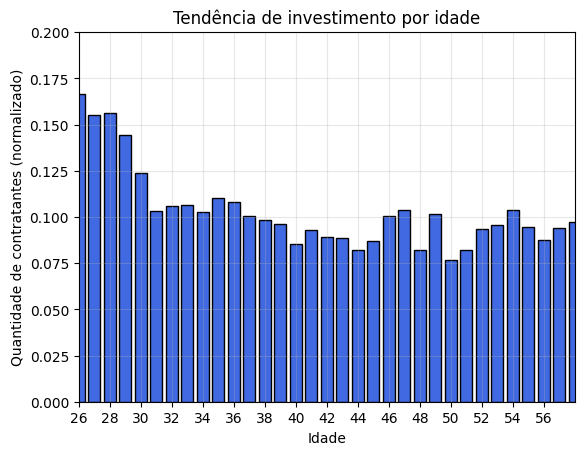

In [30]:
df_idade = df[['age','y']]
df_yes = df_idade[df_idade['y']=='yes'].groupby('age',as_index=False).count()

df_total_por_idade = df[['age','y']].groupby('age',as_index=False).count()

plt.figure()
plt.grid(alpha=0.3)

plt.bar(x=df_yes['age'],height=df_yes['y'],color='skyblue',edgecolor='black')

plt.xlim(25,60)

plt.show()

df_yes['y'] = df_yes['y'] / df_total_por_idade['y']

#display(df_yes.head(10))
#display(df_total_por_idade.tail(10))

#display(df_yes.head(10))
#display(df_total_por_idade.tail(10))

plt.figure()
plt.grid(alpha=0.3)

plt.bar(x=df_yes['age'],height=df_yes['y'],color='royalblue',edgecolor='black')

plt.xlim(26,58)
plt.ylim(0,0.2)
plt.xticks(np.arange(26,58,2))

plt.ylabel('Quantidade de contratantes (normalizado)')
plt.xlabel('Idade')

plt.title('Tendência de investimento por idade')

plt.show()



---------------------------------------------------------------------------------------------------------------------------------------------

PERGUNTA: O nível de escolaridade afeta se a pessoa vai fazer a aplicação?

In [14]:
display(df.sample(10))

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
9159,33,housemaid,divorced,secondary,no,-18,yes,no,unknown,5,jun,27,8,-1,0,unknown,no
1024,43,blue-collar,single,primary,no,548,yes,no,unknown,7,may,98,1,-1,0,unknown,no
21062,54,management,divorced,tertiary,no,3222,no,no,cellular,14,aug,67,2,-1,0,unknown,no
4846,31,services,married,secondary,no,11512,yes,no,unknown,21,may,179,1,-1,0,unknown,no
25964,50,admin.,married,secondary,no,167,no,yes,cellular,19,nov,47,1,133,1,failure,no
20805,37,technician,single,secondary,no,-242,yes,no,cellular,13,aug,1149,6,-1,0,unknown,yes
13140,38,admin.,married,secondary,no,338,no,yes,cellular,8,jul,191,1,-1,0,unknown,no
12234,47,services,married,secondary,no,0,no,yes,unknown,20,jun,51,2,-1,0,unknown,no
21129,33,technician,married,secondary,no,852,no,no,cellular,14,aug,388,8,-1,0,unknown,no
32566,52,blue-collar,married,secondary,no,568,yes,no,telephone,17,apr,246,1,317,1,failure,no
